In [1]:
import tenseal as ts
import numpy as np
import time
import pandas as pd

from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error 
from sklearn.metrics import explained_variance_score
from matplotlib import pyplot as plt

# Small Random Dataset - 100 samples

Make classification samples and perform train and test split

In [2]:
sd_x, sd_y = make_regression(n_samples=100, n_features=1, n_targets=1, bias=5.0, noise=30.0, random_state=42)
print("X Minimum: ", sd_x.min())
print("X Maximum: ", sd_x.max())

sd_x_train, sd_x_test, sd_y_train, sd_y_test = train_test_split(sd_x, sd_y, test_size=0.1, random_state=42)

X Minimum:  -2.6197451040897444
X Maximum:  1.8522781845089378


Perform Standard Scaler on train and test sets

In [3]:
sd_scaler = StandardScaler()
sd_x_train = sd_scaler.fit_transform(sd_x_train)
sd_x_test = sd_scaler.transform(sd_x_test)

sd_y_train = sd_y_train.reshape(-1, 1)
sd_y_test = sd_y_test.reshape(-1, 1)

Evaluate number of training and testing samples from train/test split

In [4]:
sd_num_x_training = len(sd_x_train)
sd_num_x_test = len(sd_x_test)
sd_num_y_training = len(sd_y_train)
sd_num_y_test = len(sd_y_test)

print("Number of x training: ", sd_num_x_training)
print("Number of x test: ", sd_num_x_test)
print("Number of y training: ", sd_num_y_training)
print("Number of y test: ", sd_num_y_test)

Number of x training:  90
Number of x test:  10
Number of y training:  90
Number of y test:  10


In [5]:
print("sd_x_train shape: ", sd_x_train.shape)
print("sd_x_test shape: ", sd_x_test.shape)
print("sd_y_train shape: ", sd_y_train.shape)
print("sd_y_test shape: ", sd_y_train.shape) 

sd_x_train shape:  (90, 1)
sd_x_test shape:  (10, 1)
sd_y_train shape:  (90, 1)
sd_y_test shape:  (90, 1)


Initialise Model and Perform Fitting and Prediction

In [6]:
sd_total_start_time = time.time()

sd_model = LinearRegression()

sd_ml_start_time = time.time()

sd_model.fit(sd_x_train, sd_y_train)
sd_y_pred_clear = sd_model.predict(sd_x_test)

sd_ml_end_time = time.time()

Evaluate accuracy performed on the cleartext during prediction

In [7]:
sd_clear_mse = mean_squared_error(sd_y_test, sd_y_pred_clear)
sd_clear_mae = mean_absolute_error(sd_y_test, sd_y_pred_clear)
sd_clear_mape = mean_absolute_percentage_error(sd_y_test, sd_y_pred_clear)
sd_clear_r2 = r2_score(sd_y_test, sd_y_pred_clear)
sd_clear_explained_var = explained_variance_score(sd_y_test, sd_y_pred_clear)
sd_ml_elapsed_time = sd_ml_end_time - sd_ml_start_time

print("Mean Squared Error (MSE):", sd_clear_mse)
print("Mean Absolute Error (MAE):", sd_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", sd_clear_mape)
print("R-squared Score (R²):", sd_clear_r2)
print("Explained Variance Score:", sd_clear_explained_var)
print(f"Time it took for ML to make predictions: {sd_ml_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 1159.202712101835
Mean Absolute Error (MAE): 29.115786025100782
Mean Absolute Percentage Error (MAPE): 1.0372469587332673
R-squared Score (R²): 0.6715370856471194
Explained Variance Score: 0.8225241052707661
Time it took for ML to make predictions: 0.00301 seconds


Prediction v Actual Plot - Cleartext

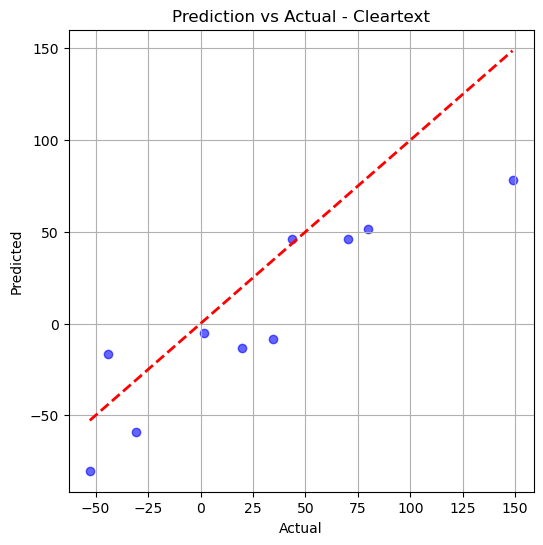

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(sd_y_test, sd_y_pred_clear, color='blue', alpha=0.6)
plt.plot([sd_y_test.min(), sd_y_test.max()],
         [sd_y_test.min(), sd_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - Cleartext")
plt.grid(True)
plt.show()

Residual Plot - Cleartext

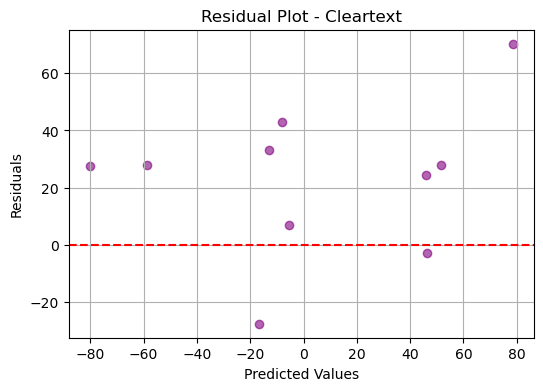

In [9]:
sd_clear_residuals = sd_y_test - sd_y_pred_clear

plt.figure(figsize=(6, 4))
plt.scatter(sd_y_pred_clear, sd_clear_residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Cleartext")
plt.grid(True)
plt.show()

Residual Histogram - Cleartext

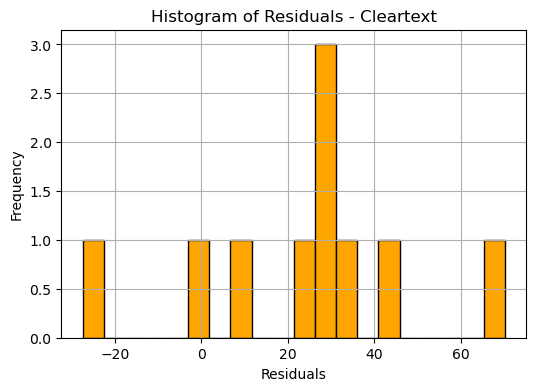

In [10]:
plt.figure(figsize=(6, 4))
plt.hist(sd_clear_residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - Cleartext")
plt.grid(True)
plt.show()

Set up the TenSEAL Context

In [11]:
sd_poly_mod_degree = 8192
sd_coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]

sd_ctx = ts.context(ts.SCHEME_TYPE.CKKS, sd_poly_mod_degree, -1, sd_coeff_mod_bit_sizes)
sd_ctx.global_scale = 2 ** 21
sd_ctx.generate_galois_keys()

Epoch-Based Encrypted Training Loop

In [12]:
sd_fhe_prediction_start_time = time.time()

sd_weights = sd_model.coef_.flatten()
sd_bias = sd_model.intercept_[0]

SD_EPOCHS = 10
SD_LEARNING_RATE = 0.05

for epoch in range(SD_EPOCHS):
    delta_w = np.zeros_like(sd_weights)
    delta_b = 0

    for i in range(len(sd_x_train)):
        x = sd_x_train[i].tolist()
        y = sd_y_train[i][0]

        enc_x = ts.ckks_vector(sd_ctx, x)
        enc_w = ts.ckks_vector(sd_ctx, sd_weights.tolist())
        enc_b = ts.ckks_vector(sd_ctx, [sd_bias])

        enc_out = enc_x.dot(enc_w) + enc_b
        pred = enc_out.decrypt()[0]

        error = pred - y
        delta_w += error * np.array(x)
        delta_b += error

    REGULARIZATION = 0.05
    sd_weights -= SD_LEARNING_RATE * ((delta_w / len(sd_x_train)) + REGULARIZATION * sd_weights)
    sd_bias -= SD_LEARNING_RATE * (delta_b / len(sd_x_train))

    print(f"Epoch {epoch+1} completed.")

Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.
Epoch 6 completed.
Epoch 7 completed.
Epoch 8 completed.
Epoch 9 completed.
Epoch 10 completed.


Encrypted Prediction After Training

In [13]:
sd_y_pred_encrypted = []

for i in range(len(sd_x_test)):
    x = sd_x_test[i].tolist()
    enc_x = ts.ckks_vector(sd_ctx, x)
    enc_w = ts.ckks_vector(sd_ctx, sd_weights)
    enc_b = ts.ckks_vector(sd_ctx, [sd_bias])
    
    enc_out = enc_x.dot(enc_w) + enc_b
    pred = enc_out.decrypt()[0]
    
    sd_y_pred_encrypted.append(pred)
    
sd_y_pred_encrypted = np.array(sd_y_pred_encrypted).reshape(-1, 1)

sd_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [14]:
sd_fhe_mse = mean_squared_error(sd_y_test, sd_y_pred_encrypted)
sd_fhe_mae = mean_absolute_error(sd_y_test, sd_y_pred_encrypted)
sd_fhe_mape = mean_absolute_percentage_error(sd_y_test, sd_y_pred_encrypted)
sd_fhe_r2 = r2_score(sd_y_test, sd_y_pred_encrypted)
sd_fhe_explained_var = explained_variance_score(sd_y_test, sd_y_pred_encrypted)
sd_fhe_elapsed_time = sd_fhe_prediction_end_time - sd_fhe_prediction_start_time

print("Mean Squared Error (MSE):", sd_clear_mse)
print("Mean Absolute Error (MAE):", sd_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", sd_clear_mape)
print("R-squared Score (R²):", sd_clear_r2)
print("Explained Variance Score:", sd_clear_explained_var)
print(f"Time it took for FHE to make predictions: {sd_fhe_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 1159.202712101835
Mean Absolute Error (MAE): 29.115786025100782
Mean Absolute Percentage Error (MAPE): 1.0372469587332673
R-squared Score (R²): 0.6715370856471194
Explained Variance Score: 0.8225241052707661
Time it took for FHE to make predictions: 21.19967 seconds


Prediction v Actual Plot - FHE

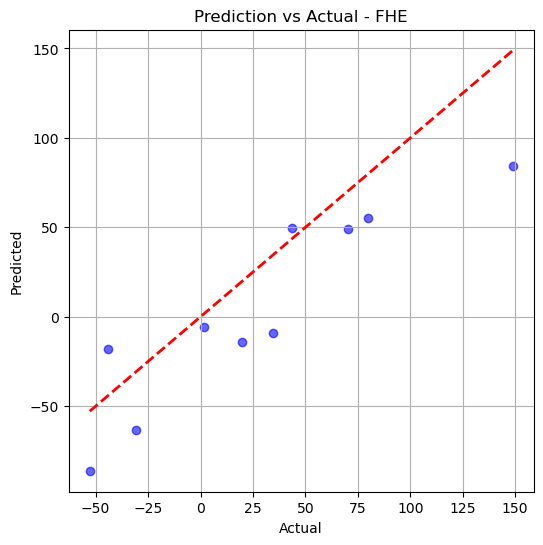

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(sd_y_test, sd_y_pred_encrypted, color='blue', alpha=0.6)
plt.plot([sd_y_test.min(), sd_y_test.max()],
         [sd_y_test.min(), sd_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - FHE")
plt.grid(True)
plt.show()

Residual Plot - FHE

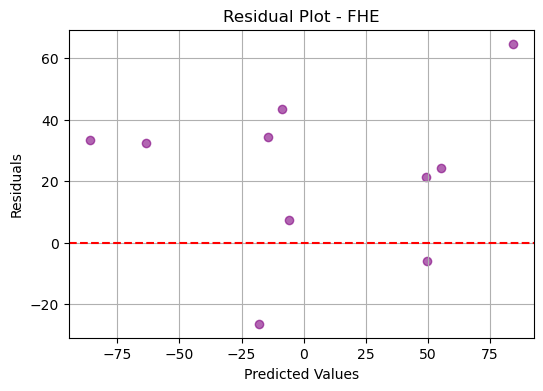

In [16]:
sd_fhe_residuals = sd_y_test - sd_y_pred_encrypted

plt.figure(figsize=(6, 4))
plt.scatter(sd_y_pred_encrypted, sd_fhe_residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - FHE")
plt.grid(True)
plt.show()

Residual Histogram - FHE

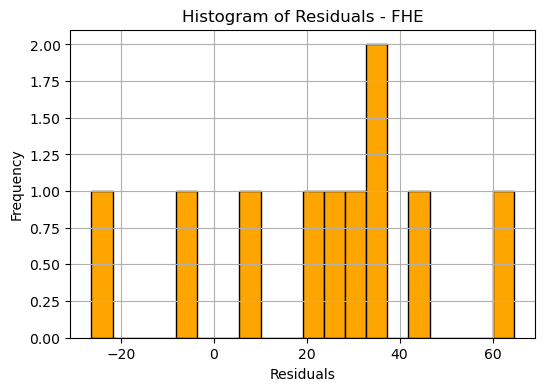

In [17]:
plt.figure(figsize=(6, 4))
plt.hist(sd_fhe_residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - FHE")
plt.grid(True)
plt.show()

Evaluation of Model

In [18]:
sd_y_pred_cleartext_flat = sd_y_pred_clear.ravel()
sd_y_pred_encrypted_flat = sd_y_pred_encrypted.ravel()
sd_y_test_flat = sd_y_test.ravel()

sd_comparison_df = pd.DataFrame({
    "Index": np.arange(len(sd_y_test)),
    "Cleartext Prediction": sd_y_pred_cleartext_flat,
    "Encrypted Prediction": sd_y_pred_encrypted_flat,
    "True Label": sd_y_test_flat
})

print("Per-sample Comparison:")
display(sd_comparison_df)

sd_total_end_time = time.time()
sd_total_elapsed_time = sd_total_end_time - sd_total_start_time
print(f"Total time for Model's to Run: {sd_total_elapsed_time:.5f} seconds")

Per-sample Comparison:


,Index,Cleartext Prediction,Encrypted Prediction,True Label
0,0,-58.918028,-63.337717,-30.967345
1,1,78.437252,84.095172,148.721588
2,2,45.868032,49.097250,70.396144
3,3,-13.097796,-14.177563,20.000109
4,4,-5.366041,-5.806707,1.674345
5,5,-8.182594,-8.821837,34.594155
6,6,-16.701512,-17.891775,-44.217658
7,7,-80.203773,-86.084971,-52.797791
8,8,46.327013,49.669007,43.682970
9,9,51.680956,55.435586,79.594475


Total time for Model's to Run: 22.31905 seconds


# Medium Random Dataset - 1000 samples

Make classification samples and perform train and test split

In [19]:
md_x, md_y = make_regression(n_samples=1000, n_features=1, n_targets=1, bias=5.0, noise=30.0, random_state=42)
print("X Minimum: ", md_x.min())
print("X Maximum: ", md_x.max())

md_x_train, md_x_test, md_y_train, md_y_test = train_test_split(md_x, md_y, test_size=0.1, random_state=42)

X Minimum:  -3.2412673400690726
X Maximum:  3.8527314906547208


Perform Standard Scaler on train and test sets

In [20]:
md_scaler = StandardScaler()
md_x_train = md_scaler.fit_transform(md_x_train)
md_x_test = md_scaler.transform(md_x_test)

md_y_train = md_y_train.reshape(-1, 1)
md_y_test = md_y_test.reshape(-1, 1)

Evaluate number of training and testing samples from train/test split

In [21]:
md_num_x_training = len(md_x_train)
md_num_x_test = len(md_x_test)
md_num_y_training = len(md_y_train)
md_num_y_test = len(md_y_test)

print("Number of x training: ", md_num_x_training)
print("Number of x test: ", md_num_x_test)
print("Number of y training: ", md_num_y_training)
print("Number of y test: ", md_num_y_test)

Number of x training:  900
Number of x test:  100
Number of y training:  900
Number of y test:  100


In [22]:
print("md_x_train shape: ", md_x_train.shape)
print("md_x_test shape: ", md_x_test.shape)
print("md_y_train shape: ", md_y_train.shape)
print("md_y_test shape: ", md_y_train.shape)

md_x_train shape:  (900, 1)
md_x_test shape:  (100, 1)
md_y_train shape:  (900, 1)
md_y_test shape:  (900, 1)


Initialise and Perform Fitting and Prediction

In [23]:
md_total_start_time = time.time()

md_model = LinearRegression()

md_ml_start_time = time.time()

md_model.fit(md_x_train, md_y_train)
md_y_pred_clear = md_model.predict(md_x_test)

md_ml_end_time = time.time()

Evaluate accuracy performed on the cleartext during prediction

In [24]:
md_clear_mse = mean_squared_error(md_y_test, md_y_pred_clear)
md_clear_mae = mean_absolute_error(md_y_test, md_y_pred_clear)
md_clear_mape = mean_absolute_percentage_error(md_y_test, md_y_pred_clear)
md_clear_r2 = r2_score(md_y_test, md_y_pred_clear)
md_clear_explained_var = explained_variance_score(md_y_test, md_y_pred_clear)
md_ml_elapsed_time = md_ml_end_time - md_ml_start_time

print("Mean Squared Error (MSE):", md_clear_mse)
print("Mean Absolute Error (MAE):", md_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", md_clear_mape)
print("R-squared Score (R²):", md_clear_r2)
print("Explained Variance Score:", md_clear_explained_var)
print(f"Time it took for ML to make predictions: {md_ml_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 1031.3273363615015
Mean Absolute Error (MAE): 25.58383911340344
Mean Absolute Percentage Error (MAPE): 1.3407949645244435
R-squared Score (R²): 0.18885530359768443
Explained Variance Score: 0.1922963281274681
Time it took for ML to make predictions: 0.00098 seconds


Prediction v Actual Plot - Cleartext

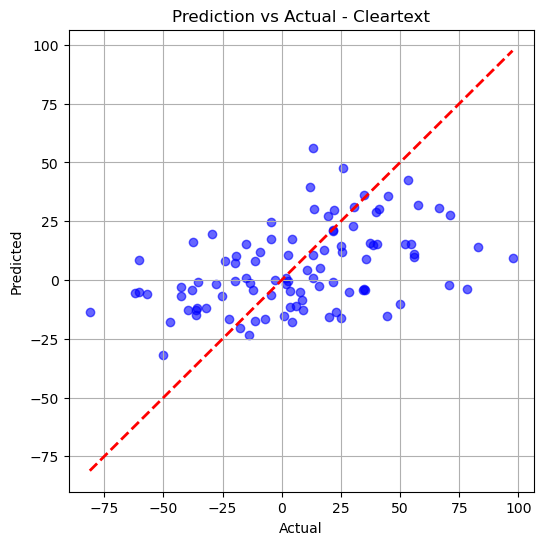

In [25]:
plt.figure(figsize=(6, 6))
plt.scatter(md_y_test, md_y_pred_clear, color='blue', alpha=0.6)
plt.plot([md_y_test.min(), md_y_test.max()],
         [md_y_test.min(), md_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - Cleartext")
plt.grid(True)
plt.show()

Residual Plot - Cleartext

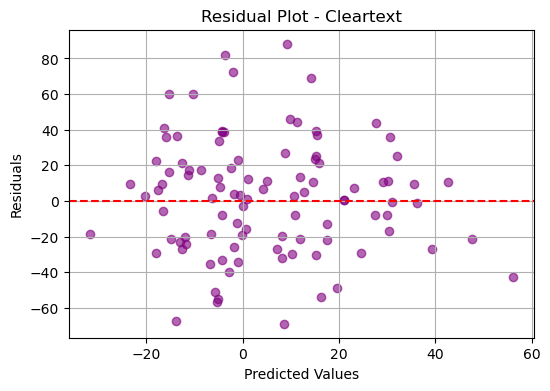

In [26]:
md_clear_residuals = md_y_test - md_y_pred_clear

plt.figure(figsize=(6, 4))
plt.scatter(md_y_pred_clear, md_clear_residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Cleartext")
plt.grid(True)
plt.show()

Residual Histogram - Cleartext

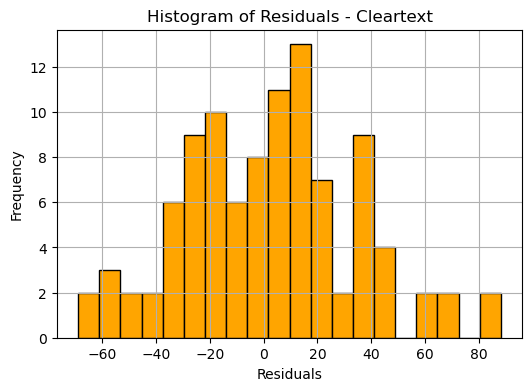

In [27]:
plt.figure(figsize=(6, 4))
plt.hist(md_clear_residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - Cleartext")
plt.grid(True)
plt.show()

Set up the TenSEAL Context

In [28]:
md_poly_mod_degree = 8192
md_coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]

md_ctx = ts.context(ts.SCHEME_TYPE.CKKS, md_poly_mod_degree, -1, md_coeff_mod_bit_sizes)
md_ctx.global_scale = 2 ** 21
md_ctx.generate_galois_keys()

Epoch-Based Encrypted Training Loop

In [29]:
md_fhe_prediction_start_time = time.time()

md_weights = md_model.coef_.flatten()
md_bias = md_model.intercept_[0]

MD_EPOCHS = 10
MD_LEARNING_RATE = 0.05

for epoch in range(MD_EPOCHS):
    delta_w = np.zeros_like(md_weights)
    delta_b = 0

    for i in range(len(md_x_train)):
        x = md_x_train[i].tolist()
        y = md_y_train[i][0]

        enc_x = ts.ckks_vector(md_ctx, x)
        enc_w = ts.ckks_vector(md_ctx, md_weights.tolist())
        enc_b = ts.ckks_vector(md_ctx, [md_bias])

        enc_out = enc_x.dot(enc_w) + enc_b
        pred = enc_out.decrypt()[0]

        error = pred - y
        delta_w += error * np.array(x)
        delta_b += error

    REGULARIZATION = 0.05
    md_weights -= MD_LEARNING_RATE * ((delta_w / len(md_x_train)) + REGULARIZATION * md_weights)
    md_bias -= MD_LEARNING_RATE * (delta_b / len(md_x_train))

    print(f"Epoch {epoch+1} completed.")

Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.
Epoch 6 completed.
Epoch 7 completed.
Epoch 8 completed.
Epoch 9 completed.
Epoch 10 completed.


Encrypted Prediction After Training

In [30]:
md_y_pred_encrypted = []

for i in range(len(md_x_test)):
    x = md_x_test[i].tolist()
    enc_x = ts.ckks_vector(md_ctx, x)
    enc_w = ts.ckks_vector(md_ctx, md_weights)
    enc_b = ts.ckks_vector(md_ctx, [md_bias])
    
    enc_out = enc_x.dot(enc_w) + enc_b
    pred = enc_out.decrypt()[0]
    
    md_y_pred_encrypted.append(pred)
    
md_y_pred_encrypted = np.array(md_y_pred_encrypted).reshape(-1, 1)

md_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [31]:
md_fhe_mse = mean_squared_error(md_y_test, md_y_pred_encrypted)
md_fhe_mae = mean_absolute_error(md_y_test, md_y_pred_encrypted)
md_fhe_mape = mean_absolute_percentage_error(md_y_test, md_y_pred_encrypted)
md_fhe_r2 = r2_score(md_y_test, md_y_pred_encrypted)
md_fhe_explained_var = explained_variance_score(md_y_test, md_y_pred_encrypted)
md_fhe_elapsed_time = md_fhe_prediction_end_time - md_fhe_prediction_start_time

print("Mean Squared Error (MSE):", md_clear_mse)
print("Mean Absolute Error (MAE):", md_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", md_clear_mape)
print("R-squared Score (R²):", md_clear_r2)
print("Explained Variance Score:", md_clear_explained_var)
print(f"Time it took for FHE to make predictions: {md_fhe_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 1031.3273363615015
Mean Absolute Error (MAE): 25.58383911340344
Mean Absolute Percentage Error (MAPE): 1.3407949645244435
R-squared Score (R²): 0.18885530359768443
Explained Variance Score: 0.1922963281274681
Time it took for FHE to make predictions: 211.33901 seconds


Prediction v Actual Plot - FHE

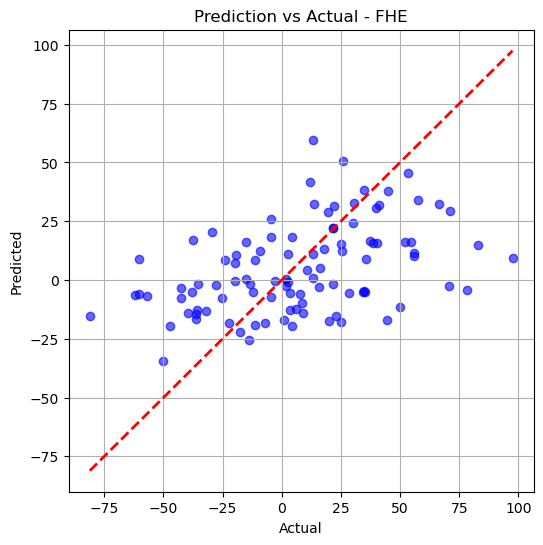

In [32]:
plt.figure(figsize=(6, 6))
plt.scatter(md_y_test, md_y_pred_encrypted, color='blue', alpha=0.6)
plt.plot([md_y_test.min(), md_y_test.max()],
         [md_y_test.min(), md_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - FHE")
plt.grid(True)
plt.show()

Residual Plot - FHE

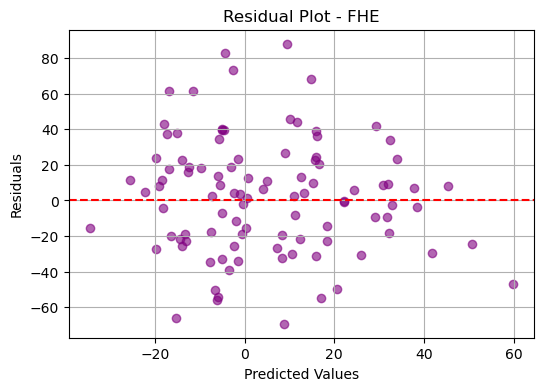

In [33]:
md_fhe_residuals = md_y_test - md_y_pred_encrypted

plt.figure(figsize=(6, 4))
plt.scatter(md_y_pred_encrypted, md_fhe_residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - FHE")
plt.grid(True)
plt.show()

Residual Histogram - FHE

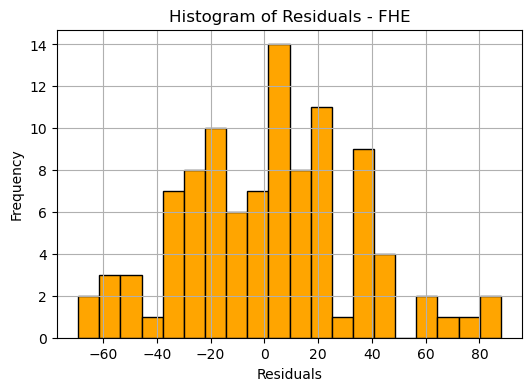

In [34]:
plt.figure(figsize=(6, 4))
plt.hist(md_fhe_residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - FHE")
plt.grid(True)
plt.show()

Evaluation of Model

In [35]:
md_y_pred_cleartext_flat = md_y_pred_clear.ravel()
md_y_pred_encrypted_flat = md_y_pred_encrypted.ravel()
md_y_test_flat = md_y_test.ravel()

md_comparison_df = pd.DataFrame({
    "Index": np.arange(len(md_y_test)),
    "Cleartext Prediction": md_y_pred_cleartext_flat,
    "Encrypted Prediction": md_y_pred_encrypted_flat,
    "True Label": md_y_test_flat
})

print("Per-sample Comparison:")
display(md_comparison_df)

md_total_end_time = time.time()
md_total_elapsed_time = md_total_end_time - md_total_start_time
print(f"Total time for Model's to Run: {md_total_elapsed_time:.5f} seconds")

Per-sample Comparison:


,Index,Cleartext Prediction,Encrypted Prediction,True Label
0,0,30.185067,32.009840,41.245869
1,1,10.762513,11.168404,2.804759
2,2,36.139588,38.409381,34.689329
3,3,-11.426811,-12.651154,3.324108
4,4,-5.801393,-6.618585,-56.794446
...,...,...,...,...
95,95,55.991435,59.706223,13.070194
96,96,-13.804106,-15.215796,-81.111148
97,97,30.889903,32.752175,30.315473
98,98,-5.440562,-6.235631,-62.020624


Total time for Model's to Run: 212.32556 seconds


# Large Random Dataset - 10,000 samples

Make classification samples and perform train and test split

In [36]:
ld_x, ld_y = make_regression(n_samples=10000, n_features=1, n_targets=1, bias=5.0, noise=30.0, random_state=42)
print("X Minimum: ", ld_x.min())
print("X Maximum: ", ld_x.max())

ld_x_train, ld_x_test, ld_y_train, ld_y_test = train_test_split(ld_x, ld_y, test_size=0.1, random_state=42)

X Minimum:  -3.9224002516183423
X Maximum:  3.9262377064363267


Perform Standard Scaler on train and test sets

In [37]:
ld_scaler = StandardScaler()
ld_x_train = ld_scaler.fit_transform(ld_x_train)
ld_x_test = ld_scaler.transform(ld_x_test)

ld_y_train = ld_y_train.reshape(-1, 1)
ld_y_test = ld_y_test.reshape(-1, 1)

Evaluate number of training and testing samples from train/test split

In [38]:
ld_num_x_training = len(ld_x_train)
ld_num_x_test = len(ld_x_test)
ld_num_y_training = len(ld_y_train)
ld_num_y_test = len(ld_y_test)

print("Number of x training: ", ld_num_x_training)
print("Number of x test: ", ld_num_x_test)
print("Number of y training: ", ld_num_y_training)
print("Number of y test: ", ld_num_y_test)

Number of x training:  9000
Number of x test:  1000
Number of y training:  9000
Number of y test:  1000


In [39]:
print("ld_x_train shape: ", ld_x_train.shape)
print("ld_x_test shape: ", ld_x_test.shape)
print("ld_y_train shape: ", ld_y_train.shape)
print("ld_y_test shape: ", ld_y_train.shape) 

ld_x_train shape:  (9000, 1)
ld_x_test shape:  (1000, 1)
ld_y_train shape:  (9000, 1)
ld_y_test shape:  (9000, 1)


Initialise Model and Perform Fitting and Prediction

In [40]:
ld_total_start_time = time.time()

ld_model = LinearRegression()

ld_ml_start_time = time.time()

ld_model.fit(ld_x_train, ld_y_train)
ld_y_pred_clear = ld_model.predict(ld_x_test)

ld_ml_end_time = time.time()

Evaluate accuracy performed on the cleartext during prediction

In [41]:
ld_clear_mse = mean_squared_error(ld_y_test, ld_y_pred_clear)
ld_clear_mae = mean_absolute_error(ld_y_test, ld_y_pred_clear)
ld_clear_mape = mean_absolute_percentage_error(ld_y_test, ld_y_pred_clear)
ld_clear_r2 = r2_score(ld_y_test, ld_y_pred_clear)
ld_clear_explained_var = explained_variance_score(ld_y_test, ld_y_pred_clear)
ld_ml_elapsed_time = ld_ml_end_time - ld_ml_start_time

print("Mean Squared Error (MSE):", ld_clear_mse)
print("Mean Absolute Error (MAE):", ld_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", ld_clear_mape)
print("R-squared Score (R²):", ld_clear_r2)
print("Explained Variance Score:", ld_clear_explained_var)
print(f"Time it took for ML to make predictions: {ld_ml_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 928.2986123768829
Mean Absolute Error (MAE): 24.223993889890792
Mean Absolute Percentage Error (MAPE): 3.458040378882394
R-squared Score (R²): 0.5256372916935322
Explained Variance Score: 0.5275093700379029
Time it took for ML to make predictions: 0.00169 seconds


Prediction v Actual Plot - Cleartext

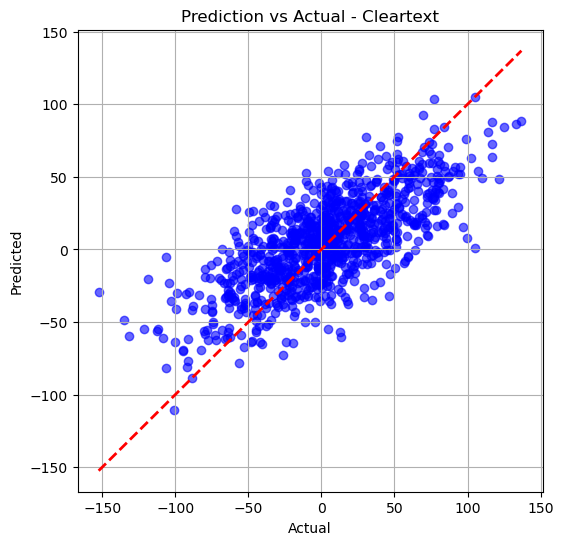

In [42]:
plt.figure(figsize=(6, 6))
plt.scatter(ld_y_test, ld_y_pred_clear, color='blue', alpha=0.6)
plt.plot([ld_y_test.min(), ld_y_test.max()],
         [ld_y_test.min(), ld_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - Cleartext")
plt.grid(True)
plt.show()

Residual Plot - Cleartext

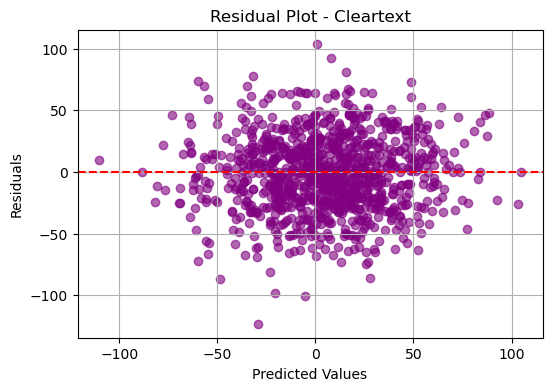

In [43]:
ld_clear_residuals = ld_y_test - ld_y_pred_clear

plt.figure(figsize=(6, 4))
plt.scatter(ld_y_pred_clear, ld_clear_residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Cleartext")
plt.grid(True)
plt.show()

Residual Histogram - Cleartext

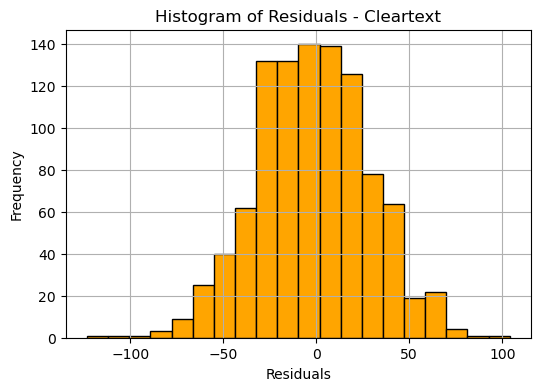

In [44]:
plt.figure(figsize=(6, 4))
plt.hist(ld_clear_residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - Cleartext")
plt.grid(True)
plt.show()

Set up the TenSEAL Context

In [45]:
ld_poly_mod_degree = 8192
ld_coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]

ld_ctx = ts.context(ts.SCHEME_TYPE.CKKS, ld_poly_mod_degree, -1, ld_coeff_mod_bit_sizes)
ld_ctx.global_scale = 2 ** 21
ld_ctx.generate_galois_keys()

Epoch-Based Encrypted Training Loop

In [46]:
ld_fhe_prediction_start_time = time.time()

ld_weights = ld_model.coef_.flatten()
ld_bias = ld_model.intercept_[0]

LD_EPOCHS = 10
LD_LEARNING_RATE = 0.05

for epoch in range(LD_EPOCHS):
    delta_w = np.zeros_like(ld_weights)
    delta_b = 0

    for i in range(len(ld_x_train)):
        x = ld_x_train[i].tolist()
        y = ld_y_train[i][0]

        enc_x = ts.ckks_vector(ld_ctx, x)
        enc_w = ts.ckks_vector(ld_ctx, ld_weights.tolist())
        enc_b = ts.ckks_vector(ld_ctx, [ld_bias])

        enc_out = enc_x.dot(enc_w) + enc_b
        pred = enc_out.decrypt()[0]

        error = pred - y
        delta_w += error * np.array(x)
        delta_b += error

    REGULARIZATION = 0.05
    ld_weights -= LD_LEARNING_RATE * ((delta_w / len(ld_x_train)) + REGULARIZATION * ld_weights)
    ld_bias -= LD_LEARNING_RATE * (delta_b / len(ld_x_train))

    print(f"Epoch {epoch+1} completed.")

Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.
Epoch 6 completed.
Epoch 7 completed.
Epoch 8 completed.
Epoch 9 completed.
Epoch 10 completed.


Encrypted Prediction After Training

In [47]:
ld_y_pred_encrypted = []

for i in range(len(ld_x_test)):
    x = ld_x_test[i].tolist()
    enc_x = ts.ckks_vector(ld_ctx, x)
    enc_w = ts.ckks_vector(ld_ctx, ld_weights)
    enc_b = ts.ckks_vector(ld_ctx, [ld_bias])
    
    enc_out = enc_x.dot(enc_w) + enc_b
    pred = enc_out.decrypt()[0]
    
    ld_y_pred_encrypted.append(pred)
    
ld_y_pred_encrypted = np.array(ld_y_pred_encrypted).reshape(-1, 1)

ld_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [48]:
ld_fhe_mse = mean_squared_error(ld_y_test, ld_y_pred_encrypted)
ld_fhe_mae = mean_absolute_error(ld_y_test, ld_y_pred_encrypted)
ld_fhe_mape = mean_absolute_percentage_error(ld_y_test, ld_y_pred_encrypted)
ld_fhe_r2 = r2_score(ld_y_test, ld_y_pred_encrypted)
ld_fhe_explained_var = explained_variance_score(ld_y_test, ld_y_pred_encrypted)
ld_fhe_elapsed_time = ld_fhe_prediction_end_time - ld_fhe_prediction_start_time

print("Mean Squared Error (MSE):", ld_clear_mse)
print("Mean Absolute Error (MAE):", ld_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", ld_clear_mape)
print("R-squared Score (R²):", ld_clear_r2)
print("Explained Variance Score:", ld_clear_explained_var)
print(f"Time it took for FHE to make predictions: {ld_fhe_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 928.2986123768829
Mean Absolute Error (MAE): 24.223993889890792
Mean Absolute Percentage Error (MAPE): 3.458040378882394
R-squared Score (R²): 0.5256372916935322
Explained Variance Score: 0.5275093700379029
Time it took for FHE to make predictions: 2111.80941 seconds


Prediction v Actual Plot - FHE

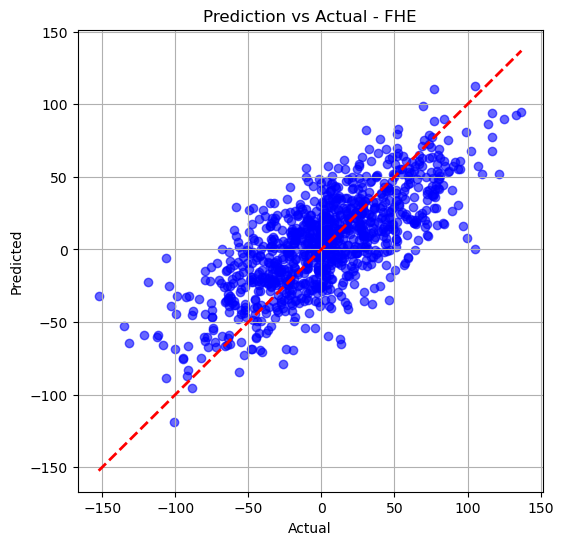

In [49]:
plt.figure(figsize=(6, 6))
plt.scatter(ld_y_test, ld_y_pred_encrypted, color='blue', alpha=0.6)
plt.plot([ld_y_test.min(), ld_y_test.max()],
         [ld_y_test.min(), ld_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - FHE")
plt.grid(True)
plt.show()

Residual Plot - FHE

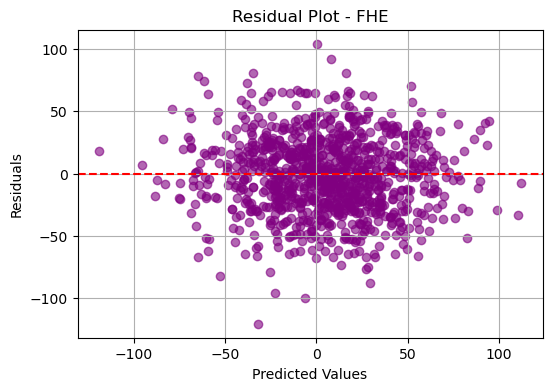

In [50]:
ld_fhe_residuals = ld_y_test - ld_y_pred_encrypted

plt.figure(figsize=(6, 4))
plt.scatter(ld_y_pred_encrypted, ld_fhe_residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - FHE")
plt.grid(True)
plt.show()

Residual Histogram - FHE

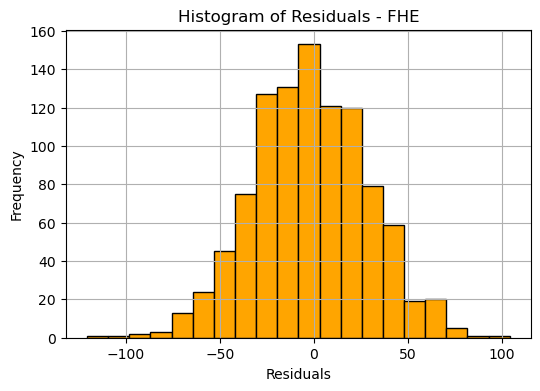

In [51]:
plt.figure(figsize=(6, 4))
plt.hist(ld_fhe_residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - FHE")
plt.grid(True)
plt.show()

Evaluation of Model

In [52]:
ld_y_pred_cleartext_flat = ld_y_pred_clear.ravel()
ld_y_pred_encrypted_flat = ld_y_pred_encrypted.ravel()
ld_y_test_flat = ld_y_test.ravel()

ld_comparison_df = pd.DataFrame({
    "Index": np.arange(len(ld_y_test)),
    "Cleartext Prediction": ld_y_pred_cleartext_flat,
    "Encrypted Prediction": ld_y_pred_encrypted_flat,
    "True Label": ld_y_test_flat
})

print("Per-sample Comparison:")
display(ld_comparison_df)

ld_total_end_time = time.time()
ld_total_elapsed_time = ld_total_end_time - ld_total_start_time
print(f"Total time for Model's to Run: {ld_total_elapsed_time:.5f} seconds")

Per-sample Comparison:


,Index,Cleartext Prediction,Encrypted Prediction,True Label
0,0,-2.185812,-2.758564,24.081621
1,1,-13.658964,-15.067120,21.390531
2,2,-0.514493,-0.947731,-23.869666
3,3,4.079477,3.957667,13.499221
4,4,-54.453321,-58.858844,-63.360751
...,...,...,...,...
995,995,30.099980,31.884558,-32.363835
996,996,-1.700038,-2.235232,5.552788
997,997,-15.520803,-17.094577,-43.285375
998,998,33.374651,35.417774,32.150476


Total time for Model's to Run: 2112.81150 seconds


# High Random Dataset - 100,000 samples

Make classification samples and perform train and test split

In [53]:
hd_x, hd_y = make_regression(n_samples=100000, n_features=1, n_targets=1, bias=5.0, noise=30.0, random_state=42)
print("X Minimum: ", hd_x.min())
print("X Maximum: ", hd_x.max())

hd_x_train, hd_x_test, hd_y_train, hd_y_test = train_test_split(hd_x, hd_y, test_size=0.1, random_state=42)

X Minimum:  -4.4656038635288775
X Maximum:  4.479084251025757


Perform Standard Scaler on train and test sets

In [54]:
hd_scaler = StandardScaler()
hd_x_train = hd_scaler.fit_transform(hd_x_train)
hd_x_test = hd_scaler.transform(hd_x_test)

hd_y_train = hd_y_train.reshape(-1, 1)
hd_y_test = hd_y_test.reshape(-1, 1)

Evaluate number of training and testing samples from train/test split

In [55]:
hd_num_x_training = len(hd_x_train)
hd_num_x_test = len(hd_x_test)
hd_num_y_training = len(hd_y_train)
hd_num_y_test = len(hd_y_test)

print("Number of x training: ", hd_num_x_training)
print("Number of x test: ", hd_num_x_test)
print("Number of y training: ", hd_num_y_training)
print("Number of y test: ", hd_num_y_test)

Number of x training:  90000
Number of x test:  10000
Number of y training:  90000
Number of y test:  10000


In [56]:
print("hd_x_train shape: ", hd_x_train.shape)
print("hd_x_test shape: ", hd_x_test.shape)
print("hd_y_train shape: ", hd_y_train.shape)
print("hd_y_test shape: ", hd_y_train.shape) 

hd_x_train shape:  (90000, 1)
hd_x_test shape:  (10000, 1)
hd_y_train shape:  (90000, 1)
hd_y_test shape:  (90000, 1)


Initialise Model and Perform Fitting and Prediction

In [57]:
hd_total_start_time = time.time()

hd_model = LinearRegression()

hd_ml_start_time = time.time()

hd_model.fit(hd_x_train, hd_y_train)
hd_y_pred_clear = hd_model.predict(hd_x_test)

hd_ml_end_time = time.time()

Evaluate accuracy performed on the cleartext during prediction

In [58]:
hd_clear_mse = mean_squared_error(hd_y_test, hd_y_pred_clear)
hd_clear_mae = mean_absolute_error(hd_y_test, hd_y_pred_clear)
hd_clear_mape = mean_absolute_percentage_error(hd_y_test, hd_y_pred_clear)
hd_clear_r2 = r2_score(hd_y_test, hd_y_pred_clear)
hd_clear_explained_var = explained_variance_score(hd_y_test, hd_y_pred_clear)
hd_ml_elapsed_time = hd_ml_end_time - hd_ml_start_time

print("Mean Squared Error (MSE):", hd_clear_mse)
print("Mean Absolute Error (MAE):", hd_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", hd_clear_mape)
print("R-squared Score (R²):", hd_clear_r2)
print("Explained Variance Score:", hd_clear_explained_var)
print(f"Time it took for ML to make predictions: {hd_ml_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 919.3008770385097
Mean Absolute Error (MAE): 24.3162726393096
Mean Absolute Percentage Error (MAPE): 2.4929153332098295
R-squared Score (R²): 0.4698059200074961
Explained Variance Score: 0.4698539640482867
Time it took for ML to make predictions: 0.00629 seconds


Prediction v Actual Plot - Cleartext

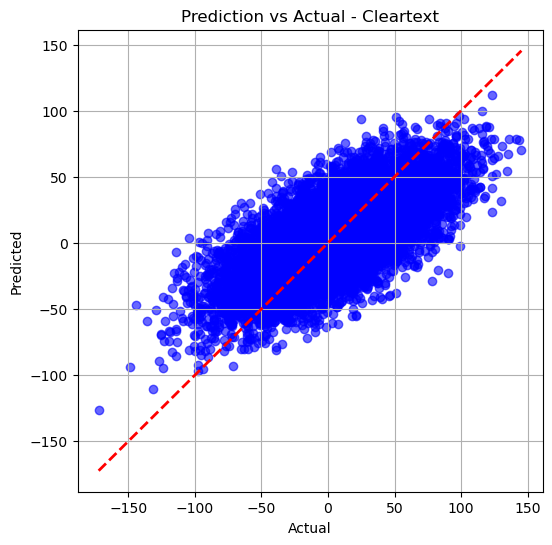

In [59]:
plt.figure(figsize=(6, 6))
plt.scatter(hd_y_test, hd_y_pred_clear, color='blue', alpha=0.6)
plt.plot([hd_y_test.min(), hd_y_test.max()],
         [hd_y_test.min(), hd_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - Cleartext")
plt.grid(True)
plt.show()

Residual Plot - Cleartext

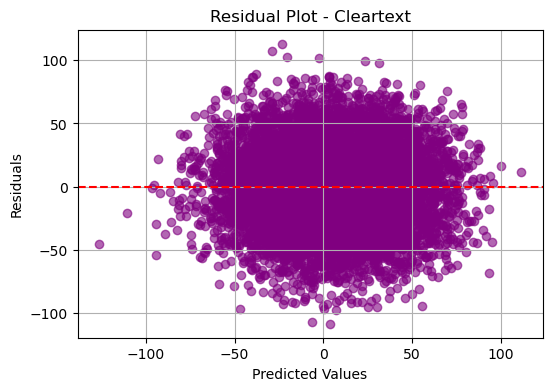

In [60]:
hd_clear_residuals = hd_y_test - hd_y_pred_clear

plt.figure(figsize=(6, 4))
plt.scatter(hd_y_pred_clear, hd_clear_residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Cleartext")
plt.grid(True)
plt.show()

Residual Histogram - Cleartext

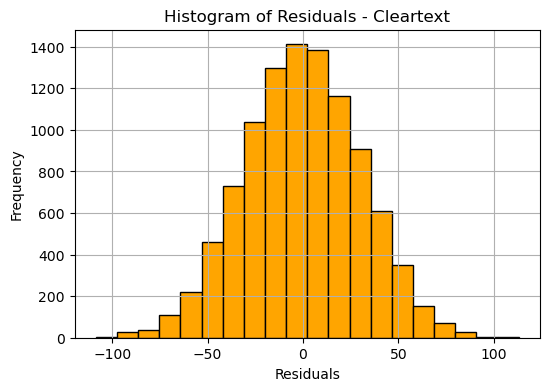

In [61]:
plt.figure(figsize=(6, 4))
plt.hist(hd_clear_residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - Cleartext")
plt.grid(True)
plt.show()

Set up the TenSEAL Context

In [62]:
hd_poly_mod_degree = 8192
hd_coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]

hd_ctx = ts.context(ts.SCHEME_TYPE.CKKS, hd_poly_mod_degree, -1, hd_coeff_mod_bit_sizes)
hd_ctx.global_scale = 2 ** 21
hd_ctx.generate_galois_keys()

Epoch-Based Encrypted Training Loop

In [63]:
hd_fhe_prediction_start_time = time.time()

hd_weights = hd_model.coef_.flatten()
hd_bias = hd_model.intercept_[0]

HD_EPOCHS = 10
HD_LEARNING_RATE = 0.05

for epoch in range(HD_EPOCHS):
    delta_w = np.zeros_like(hd_weights)
    delta_b = 0

    for i in range(len(hd_x_train)):
        x = hd_x_train[i].tolist()
        y = hd_y_train[i][0]

        enc_x = ts.ckks_vector(hd_ctx, x)
        enc_w = ts.ckks_vector(hd_ctx, hd_weights.tolist())
        enc_b = ts.ckks_vector(hd_ctx, [hd_bias])

        enc_out = enc_x.dot(enc_w) + enc_b
        pred = enc_out.decrypt()[0]

        error = pred - y
        delta_w += error * np.array(x)
        delta_b += error

    REGULARIZATION = 0.05
    hd_weights -= HD_LEARNING_RATE * ((delta_w / len(hd_x_train)) + REGULARIZATION * hd_weights)
    hd_bias -= HD_LEARNING_RATE * (delta_b / len(hd_x_train))

    print(f"Epoch {epoch+1} completed.")

Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.
Epoch 6 completed.
Epoch 7 completed.
Epoch 8 completed.
Epoch 9 completed.
Epoch 10 completed.


Encrypted Prediction After Training

In [64]:
hd_y_pred_encrypted = []

for i in range(len(hd_x_test)):
    x = hd_x_test[i].tolist()
    enc_x = ts.ckks_vector(hd_ctx, x)
    enc_w = ts.ckks_vector(hd_ctx, hd_weights)
    enc_b = ts.ckks_vector(hd_ctx, [hd_bias])
    
    enc_out = enc_x.dot(enc_w) + enc_b
    pred = enc_out.decrypt()[0]
    
    hd_y_pred_encrypted.append(pred)
    
hd_y_pred_encrypted = np.array(hd_y_pred_encrypted).reshape(-1, 1)

hd_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [65]:
hd_fhe_mse = mean_squared_error(hd_y_test, hd_y_pred_encrypted)
hd_fhe_mae = mean_absolute_error(hd_y_test, hd_y_pred_encrypted)
hd_fhe_mape = mean_absolute_percentage_error(hd_y_test, hd_y_pred_encrypted)
hd_fhe_r2 = r2_score(hd_y_test, hd_y_pred_encrypted)
hd_fhe_explained_var = explained_variance_score(hd_y_test, hd_y_pred_encrypted)
hd_fhe_elapsed_time = hd_fhe_prediction_end_time - hd_fhe_prediction_start_time

print("Mean Squared Error (MSE):", hd_clear_mse)
print("Mean Absolute Error (MAE):", hd_clear_mae)
print("Mean Absolute Percentage Error (MAPE):", hd_clear_mape)
print("R-squared Score (R²):", hd_clear_r2)
print("Explained Variance Score:", hd_clear_explained_var)
print(f"Time it took for FHE to make predictions: {hd_fhe_elapsed_time:.5f} seconds")

Mean Squared Error (MSE): 919.3008770385097
Mean Absolute Error (MAE): 24.3162726393096
Mean Absolute Percentage Error (MAPE): 2.4929153332098295
R-squared Score (R²): 0.4698059200074961
Explained Variance Score: 0.4698539640482867
Time it took for FHE to make predictions: 16392.74330 seconds


Prediction v Actual Plot - FHE

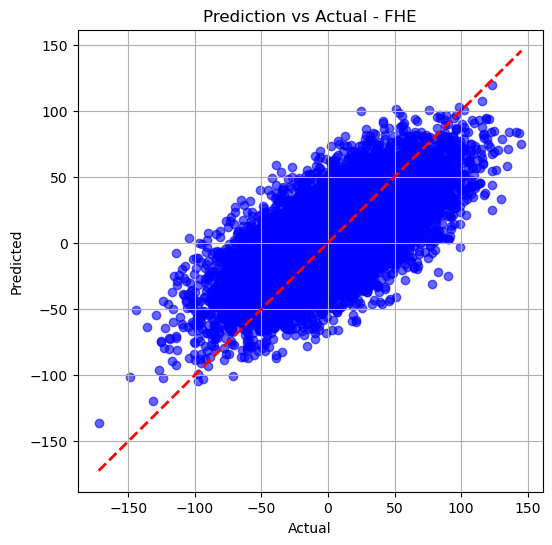

In [66]:
plt.figure(figsize=(6, 6))
plt.scatter(hd_y_test, hd_y_pred_encrypted, color='blue', alpha=0.6)
plt.plot([hd_y_test.min(), hd_y_test.max()],
         [hd_y_test.min(), hd_y_test.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual - FHE")
plt.grid(True)
plt.show()

Residual Plot - FHE

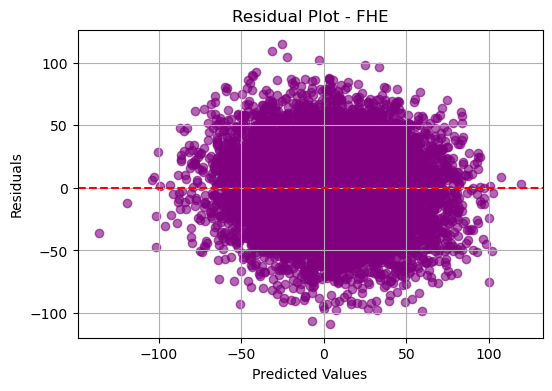

In [67]:
hd_fhe_residuals = hd_y_test - hd_y_pred_encrypted

plt.figure(figsize=(6, 4))
plt.scatter(hd_y_pred_encrypted, hd_fhe_residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - FHE")
plt.grid(True)
plt.show()

Residual Histogram - FHE

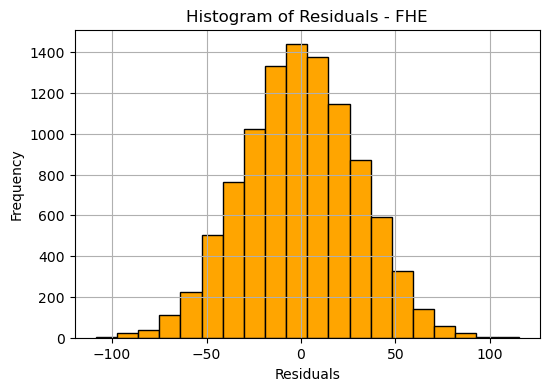

In [68]:
plt.figure(figsize=(6, 4))
plt.hist(hd_fhe_residuals, bins=20, color='orange', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals - FHE")
plt.grid(True)
plt.show()

Evaluation of Model

In [69]:
hd_y_pred_cleartext_flat = hd_y_pred_clear.ravel()
hd_y_pred_encrypted_flat = hd_y_pred_encrypted.ravel()
hd_y_test_flat = hd_y_test.ravel()

hd_comparison_df = pd.DataFrame({
    "Index": np.arange(len(hd_y_test)),
    "Cleartext Prediction": hd_y_pred_cleartext_flat,
    "Encrypted Prediction": hd_y_pred_encrypted_flat,
    "True Label": hd_y_test_flat
})

print("Per-sample Comparison:")
display(hd_comparison_df)

hd_total_end_time = time.time()
hd_total_elapsed_time = hd_total_end_time - hd_total_start_time
print(f"Total time for Model's to Run: {hd_total_elapsed_time:.5f} seconds")

Per-sample Comparison:


,Index,Cleartext Prediction,Encrypted Prediction,True Label
0,0,-34.140308,-37.020909,29.332670
1,1,29.244082,30.988370,47.374570
2,2,4.038729,3.957868,-19.981812
3,3,7.380407,7.575384,27.488369
4,4,8.151958,8.392527,33.900437
...,...,...,...,...
9995,9995,14.621327,15.300798,37.616810
9996,9996,-4.711928,-5.478638,-27.136075
9997,9997,-15.792002,-17.307529,-32.605055
9998,9998,31.766614,33.739399,14.682274


Total time for Model's to Run: 16393.73141 seconds


# Mega Random Dataset - 1,000,000 samples

Make classification samples and perform train and test split

In [70]:
# bd_x, bd_y = make_regression(n_samples=1000000, n_features=1, n_targets=1, bias=5.0, noise=30.0, random_state=42)
# print("X Minimum: ", bd_x.min())
# print("X Maximum: ", bd_x.max())

# bd_x_train, bd_x_test, bd_y_train, bd_y_test = train_test_split(bd_x, bd_y, test_size=0.1, random_state=42)

Perform Standard Scaler on train and test sets

In [71]:
# bd_scaler = StandardScaler()
# bd_x_train = bd_scaler.fit_transform(bd_x_train)
# bd_x_test = bd_scaler.transform(bd_x_test)

# bd_y_train = bd_y_train.reshape(-1, 1)
# bd_y_test = bd_y_test.reshape(-1, 1)

Evaluate number of training and testing samples from train/test split

In [72]:
# bd_num_x_training = len(bd_x_train)
# bd_num_x_test = len(bd_x_test)
# bd_num_y_training = len(bd_y_train)
# bd_num_y_test = len(bd_y_test)

# print("Number of x training: ", bd_num_x_training)
# print("Number of x test: ", bd_num_x_test)
# print("Number of y training: ", bd_num_y_training)
# print("Number of y test: ", bd_num_y_test)

In [73]:
# print("bd_x_train shape: ", bd_x_train.shape)
# print("bd_x_test shape: ", bd_x_test.shape)
# print("bd_y_train shape: ", bd_y_train.shape)
# print("bd_y_test shape: ", bd_y_train.shape) 

Initialise Model and Perform Fitting and Prediction

In [74]:
# bd_total_start_time = time.time()

# bd_model = LinearRegression()

# bd_ml_start_time = time.time()

# bd_model.fit(bd_x_train, bd_y_train)
# bd_y_pred_clear = bd_model.predict(bd_x_test)

# bd_ml_end_time = time.time()

Evaluate accuracy performed on the cleartext during prediction

In [75]:
# bd_clear_mse = mean_squared_error(bd_y_test, bd_y_pred_clear)
# bd_clear_mae = mean_absolute_error(bd_y_test, bd_y_pred_clear)
# bd_clear_mape = mean_absolute_percentage_error(bd_y_test, bd_y_pred_clear)
# bd_clear_r2 = r2_score(bd_y_test, bd_y_pred_clear)
# bd_clear_explained_var = explained_variance_score(bd_y_test, bd_y_pred_clear)
# bd_ml_elapsed_time = bd_ml_end_time - bd_ml_start_time

# print("Mean Squared Error (MSE):", bd_clear_mse)
# print("Mean Absolute Error (MAE):", bd_clear_mae)
# print("Mean Absolute Percentage Error (MAPE):", bd_clear_mape)
# print("R-squared Score (R²):", bd_clear_r2)
# print("Explained Variance Score:", bd_clear_explained_var)
# print(f"Time it took for ML to make predictions: {bd_ml_elapsed_time:.5f} seconds")

Prediction v Actual Plot - Cleartext

In [76]:
# plt.figure(figsize=(6, 6))
# plt.scatter(bd_y_test, bd_y_pred_clear, color='blue', alpha=0.6)
# plt.plot([bd_y_test.min(), bd_y_test.max()],
#          [bd_y_test.min(), bd_y_test.max()],
#          'r--', lw=2)
# plt.xlabel("Actual")
# plt.ylabel("Predicted")
# plt.title("Prediction vs Actual - Cleartext")
# plt.grid(True)
# plt.show()

Residual Plot - Cleartext

In [77]:
# bd_clear_residuals = bd_y_test - bd_y_pred_clear

# plt.figure(figsize=(6, 4))
# plt.scatter(bd_y_pred_clear, bd_clear_residuals, color='purple', alpha=0.6)
# plt.axhline(y=0, color='r', linestyle='--')
# plt.xlabel("Predicted Values")
# plt.ylabel("Residuals")
# plt.title("Residual Plot - Cleartext")
# plt.grid(True)
# plt.show()

Residual Histogram - Cleartext

In [78]:
# plt.figure(figsize=(6, 4))
# plt.hist(bd_clear_residuals, bins=20, color='orange', edgecolor='black')
# plt.xlabel("Residuals")
# plt.ylabel("Frequency")
# plt.title("Histogram of Residuals - Cleartext")
# plt.grid(True)
# plt.show()

Set up the TenSEAL Context

In [79]:
# bd_poly_mod_degree = 8192
# bd_coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]

# bd_ctx = ts.context(ts.SCHEME_TYPE.CKKS, bd_poly_mod_degree, -1, bd_coeff_mod_bit_sizes)
# bd_ctx.global_scale = 2 ** 21
# bd_ctx.generate_galois_keys()

Epoch-Based Encrypted Training Loop

In [80]:
# bd_fhe_prediction_start_time = time.time()

# bd_weights = bd_model.coef_.flatten()
# bd_bias = bd_model.intercept_[0]

# BD_EPOCHS = 10
# BD_LEARNING_RATE = 0.05

# for epoch in range(BD_EPOCHS):
#     delta_w = np.zeros_like(bd_weights)
#     delta_b = 0

#     for i in range(len(bd_x_train)):
#         x = bd_x_train[i].tolist()
#         y = bd_y_train[i][0]

#         enc_x = ts.ckks_vector(bd_ctx, x)
#         enc_w = ts.ckks_vector(bd_ctx, bd_weights.tolist())
#         enc_b = ts.ckks_vector(bd_ctx, [bd_bias])

#         enc_out = enc_x.dot(enc_w) + enc_b
#         pred = enc_out.decrypt()[0]

#         error = pred - y
#         delta_w += error * np.array(x)
#         delta_b += error

#     REGULARIZATION = 0.05
#     bd_weights -= BD_LEARNING_RATE * ((delta_w / len(bd_x_train)) + REGULARIZATION * bd_weights)
#     bd_bias -= BD_LEARNING_RATE * (delta_b / len(bd_x_train))

#     print(f"Epoch {epoch+1} completed.")

Encrypted Prediction After Training

In [81]:
# bd_y_pred_encrypted = []

# for i in range(len(bd_x_test)):
#     x = bd_x_test[i].tolist()
#     enc_x = ts.ckks_vector(bd_ctx, x)
#     enc_w = ts.ckks_vector(bd_ctx, bd_weights)
#     enc_b = ts.ckks_vector(bd_ctx, [bd_bias])
    
#     enc_out = enc_x.dot(enc_w) + enc_b
#     pred = enc_out.decrypt()[0]
    
#     bd_y_pred_encrypted.append(pred)
    
# bd_y_pred_encrypted = np.array(bd_y_pred_encrypted).reshape(-1, 1)

# bd_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [82]:
# bd_fhe_mse = mean_squared_error(bd_y_test, bd_y_pred_encrypted)
# bd_fhe_mae = mean_absolute_error(bd_y_test, bd_y_pred_encrypted)
# bd_fhe_mape = mean_absolute_percentage_error(bd_y_test, bd_y_pred_encrypted)
# bd_fhe_r2 = r2_score(bd_y_test, bd_y_pred_encrypted)
# bd_fhe_explained_var = explained_variance_score(bd_y_test, bd_y_pred_encrypted)
# bd_fhe_elapsed_time = bd_fhe_prediction_end_time - bd_fhe_prediction_start_time

# print("Mean Squared Error (MSE):", bd_clear_mse)
# print("Mean Absolute Error (MAE):", bd_clear_mae)
# print("Mean Absolute Percentage Error (MAPE):", bd_clear_mape)
# print("R-squared Score (R²):", bd_clear_r2)
# print("Explained Variance Score:", bd_clear_explained_var)
# print(f"Time it took for FHE to make predictions: {bd_fhe_elapsed_time:.5f} seconds")

Prediction v Actual Plot - FHE

In [83]:
# plt.figure(figsize=(6, 6))
# plt.scatter(bd_y_test, bd_y_pred_encrypted, color='blue', alpha=0.6)
# plt.plot([bd_y_test.min(), bd_y_test.max()],
#          [bd_y_test.min(), bd_y_test.max()],
#          'r--', lw=2)
# plt.xlabel("Actual")
# plt.ylabel("Predicted")
# plt.title("Prediction vs Actual - FHE")
# plt.grid(True)
# plt.show()

Residual Plot - FHE

In [84]:
# bd_fhe_residuals = bd_y_test - bd_y_pred_encrypted

# plt.figure(figsize=(6, 4))
# plt.scatter(bd_y_pred_encrypted, bd_fhe_residuals, color='purple', alpha=0.6)
# plt.axhline(y=0, color='r', linestyle='--')
# plt.xlabel("Predicted Values")
# plt.ylabel("Residuals")
# plt.title("Residual Plot - FHE")
# plt.grid(True)
# plt.show()

Residual Histogram - FHE

In [85]:
# plt.figure(figsize=(6, 4))
# plt.hist(bd_fhe_residuals, bins=20, color='orange', edgecolor='black')
# plt.xlabel("Residuals")
# plt.ylabel("Frequency")
# plt.title("Histogram of Residuals - FHE")
# plt.grid(True)
# plt.show()

Evaluation of Model

In [86]:
# bd_y_pred_cleartext_flat = bd_y_pred_clear.ravel()
# bd_y_pred_encrypted_flat = bd_y_pred_encrypted.ravel()
# bd_y_test_flat = bd_y_test.ravel()

# bd_comparison_df = pd.DataFrame({
#     "Index": np.arange(len(bd_y_test)),
#     "Cleartext Prediction": bd_y_pred_cleartext_flat,
#     "Encrypted Prediction": bd_y_pred_encrypted_flat,
#     "True Label": bd_y_test_flat
# })

# print("Per-sample Comparison:")
# display(bd_comparison_df)

# bd_total_end_time = time.time()
# bd_total_elapsed_time = bd_total_end_time - bd_total_start_time
# print(f"Total time for Model's to Run: {bd_total_elapsed_time:.5f} seconds")

# Evaluation of all results (from each model)

In [87]:
results = {
     '100 Dataset':["100", 
     f"{(sd_y_pred_encrypted.ravel() == sd_y_pred_clear.ravel()).mean() * 100:.0f}%", 
     sd_ml_elapsed_time,
     sd_clear_mse,
     sd_clear_mae,
     sd_clear_mape,
     sd_clear_r2,
     sd_clear_explained_var,
     sd_fhe_mse,
     sd_fhe_mae,
     sd_fhe_mape,
     sd_fhe_r2,
     sd_fhe_explained_var,
     sd_fhe_elapsed_time,
     sd_total_elapsed_time],
     '1000 Dataset':["100", 
     f"{(md_y_pred_encrypted.ravel() == md_y_pred_clear.ravel()).mean() * 100:.0f}%",
     md_ml_elapsed_time,
     md_clear_mse,
     md_clear_mae,
     md_clear_mape,
     md_clear_r2,
     md_clear_explained_var,
     md_fhe_mse,
     md_fhe_mae,
     md_fhe_mape,
     md_fhe_r2,
     md_fhe_explained_var,
     md_fhe_elapsed_time,
     md_total_elapsed_time],
     '10000 Dataset':["100", 
     f"{(ld_y_pred_encrypted.ravel() == ld_y_pred_clear.ravel()).mean() * 100:.0f}%",
     ld_ml_elapsed_time,
     ld_clear_mse,
     ld_clear_mae,
     ld_clear_mape,
     ld_clear_r2,
     ld_clear_explained_var,
     ld_fhe_mse,
     ld_fhe_mae,
     ld_fhe_mape,
     ld_fhe_r2,
     ld_fhe_explained_var,
     ld_fhe_elapsed_time,
     ld_total_elapsed_time],
     '100000 Dataset':["100", 
     f"{(hd_y_pred_encrypted.ravel() == hd_y_pred_clear.ravel()).mean() * 100:.0f}%",
     hd_ml_elapsed_time,
     hd_clear_mse,
     hd_clear_mae,
     hd_clear_mape,
     hd_clear_r2,
     hd_clear_explained_var,
     hd_fhe_mse,
     hd_fhe_mae,
     hd_fhe_mape,
     hd_fhe_r2,
     hd_fhe_explained_var,
     hd_fhe_elapsed_time,
     hd_total_elapsed_time]
     # '1000000 Dataset':["100", 
     # f"{(bd_y_pred_encrypted.ravel() == bd_y_pred_clear.ravel()).mean() * 100:.0f}%",
     # bd_ml_elapsed_time,
     # bd_clear_mse,
     # bd_clear_mae,
     # bd_clear_mape,
     # bd_clear_r2,
     # bd_clear_explained_var,
     # bd_fhe_mse,
     # bd_fhe_mae,
     # bd_fhe_mape,
     # bd_fhe_r2,
     # bd_fhe_explained_var,
     # bd_fhe_elapsed_time,
     # bd_total_elapsed_time]
}

headers = ['Samples', 'Similarity', 'ML Time', 'CT MSE','CT MAE', 'CT MAPE', 'CT R2', 'CT EVS', 
           'FHE MSE', 'FHE MAE', 'FHE MAPE', 'FHE R2', 'FHE EVS', 'FHE TIME', 'Total Time']

overall_results = pd.DataFrame(results, index=headers).T.round(2)
overall_results


,Samples,Similarity,ML Time,CT MSE,CT MAE,CT MAPE,CT R2,CT EVS,FHE MSE,FHE MAE,FHE MAPE,FHE R2,FHE EVS,FHE TIME,Total Time
100 Dataset,100,0%,0.003012,1159.202712,29.115786,1.037247,0.671537,0.822524,1120.765824,29.312839,1.088073,0.682428,0.830379,21.199673,22.319045
1000 Dataset,100,0%,0.000978,1031.327336,25.583839,1.340795,0.188855,0.192296,1037.149587,25.703368,1.399782,0.184276,0.187797,211.339011,212.325559
10000 Dataset,100,0%,0.001694,928.298612,24.223994,3.45804,0.525637,0.527509,929.473842,24.257764,3.676798,0.525037,0.526813,2111.809405,2112.811498
100000 Dataset,100,0%,0.006292,919.300877,24.316273,2.492915,0.469806,0.469854,926.921607,24.42588,2.656344,0.465411,0.465465,16392.743297,16393.731411
